# BCI-EDGE Case Study
## From Pacific climate variability to local hydroclimate and forest demography

> **Using CMAP's harmonized data system to connect basin-scale climate variability to local hydroclimate and forest demographic response at Barro Colorado Island (BCI)**

**Simons CMAP demonstration — BCI-EDGE, 21 September 2026**  

*Mohammad D. Ashkezari, E. Virginia Armbrust*

The analysis follows five steps:

1. **Validate a global product locally.** Compare the long BCI rain-gauge record with ERA5.
2. **Place BCI in the Pacific climate context.** Derive a Niño 3.4 SST index from CMAP OISST and visualize the 1997–98 El Niño at basin scale.
3. **Test the ENSO–BCI hydroclimate link.** Relate a pre-specified Niño 3.4 state to BCI dry-season rainfall and atmospheric demand.
4. **Compare mortality across tree size classes.** Estimate long-term mortality trajectories and the early-1980s contrast for small stems and larger trees.
5. **Examine species-level heterogeneity.** Compare the early-1980s mortality contrast among common species with explicit uncertainty and multiple-testing control.


One platform, one schema, four data sources that have never lived in the same place before:

| Axis | Table | Origin | Span |
|---|---|---|---|
| Forest demography | `tblBCI_Census` | Condit et al. 2019 (Dryad, 10.15146/5xcp-0d46) | 8 censuses, 1981-2016 |
| Rainfall at the plot | `tblBCI_Met_Monthly` | S. Paton, STRI Physical Monitoring (10.25573/data.10059458) | 1925-2024 |
| Reanalysis climate | `tblERA5_monthly_averaged_single_level` | ECMWF ERA5 | 1940-present |
| The driving ocean | `tblSST_AVHRR_OI_NRT` | NOAA OISST v2.1 | Sep 1981-present |

Every observation below is retrieved through the same API and colocalized by (time, lat, lon) - trees, rain gauges, reanalysis cells, and the equatorial Pacific, in one coordinate system.


In [11]:
# --- Setup -------------------------------------------------------------------
import time as _clock

T0 = _clock.time()

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from scipy import stats
import pycmap
import cartopy
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# First use on a machine: pycmap.API(token="YOUR_API_KEY") stores the key locally.
api = pycmap.API()
print(
    f"pycmap {pycmap.__version__} | pandas {pd.__version__} | "
    f"matplotlib {mpl.__version__} | cartopy {cartopy.__version__}"
)
assert tuple(int(x) for x in cartopy.__version__.split(".")[:2]) >= (0, 23), (
    "cartopy >= 0.23 is required for the map panels; older versions render blank "
    "GeoAxes with recent matplotlib. Update with: conda install -c conda-forge cartopy"
)

FIGS = Path("figs")
DATA_OUT = Path("derived_products")
FIGS.mkdir(exist_ok=True)
DATA_OUT.mkdir(exist_ok=True)

C = {
    "blue": "#0072B2",
    "sky": "#56B4E9",
    "orange": "#E69F00",
    "vermillion": "#D55E00",
    "green": "#009E73",
    "purple": "#CC79A7",
    "yellow": "#F0E442",
    "black": "#222222",
    "gray": "#6F6F6F",
    "lightgray": "#D9D9D9",
    "pale": "#F4F4F4",
}

mpl.rcParams.update(
    {
        "figure.dpi": 150,
        "savefig.dpi": 450,
        "savefig.bbox": "tight",
        "savefig.facecolor": "white",
        "font.family": "DejaVu Sans",
        "font.size": 10.5,
        "axes.titlesize": 11.5,
        "axes.titleweight": "semibold",
        "axes.labelsize": 10.5,
        "axes.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.labelsize": 9.2,
        "ytick.labelsize": 9.2,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "legend.frameon": False,
        "legend.fontsize": 9.0,
        "axes.grid": False,
        "lines.solid_capstyle": "round",
    }
)


def savefig(fig, stem):
    fig.savefig(FIGS / f"{stem}.png", dpi=450, bbox_inches="tight", facecolor="white")


def panel_label(ax, label, x=-0.10, y=1.03):
    ax.text(
        x, y, label, transform=ax.transAxes, fontweight="bold", fontsize=12, va="bottom", ha="left"
    )


def decimal_year(index):
    index = pd.DatetimeIndex(index)
    return index.year + (index.dayofyear - 1) / 365.25


def esat_kpa(temp_c):
    # FAO-56 saturation vapor pressure approximation over liquid water [kPa].
    temp_c = np.asarray(temp_c, dtype=float)
    return 0.6108 * np.exp(17.27 * temp_c / (temp_c + 237.3))


def dry_season_sum(monthly):
    monthly = monthly.dropna().sort_index()
    out = {}
    for y in range(monthly.index.year.min() + 1, monthly.index.year.max() + 1):
        w = monthly.loc[f"{y-1}-12-01":f"{y}-04-30"]
        if len(w) == 5 and w.notna().all():
            out[y] = float(w.sum())
    return pd.Series(out, dtype=float, name="dry_season_precip_mm")


def dry_season_mean(monthly):
    monthly = monthly.dropna().sort_index()
    out = {}
    for y in range(monthly.index.year.min() + 1, monthly.index.year.max() + 1):
        w = monthly.loc[f"{y-1}-12-01":f"{y}-04-30"]
        if len(w) == 5 and w.notna().all():
            out[y] = float(w.mean())
    return pd.Series(out, dtype=float)


def _circular_block_indices(n, block, rng):
    nblocks = int(np.ceil(n / block))
    starts = rng.integers(0, n, nblocks)
    offsets = np.arange(block)
    return np.concatenate([(s + offsets) % n for s in starts])[:n]


def bootstrap_corr(x, y, n_boot=4000, block=3, seed=20260921):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    r0 = stats.pearsonr(x, y).statistic
    rng = np.random.default_rng(seed)
    rs = []
    for _ in range(n_boot):
        ii = _circular_block_indices(len(x), min(block, len(x)), rng)
        if np.std(x[ii]) == 0 or np.std(y[ii]) == 0:
            continue
        rs.append(np.corrcoef(x[ii], y[ii])[0, 1])
    rs = np.asarray(rs)
    return r0, np.nanpercentile(rs, [2.5, 97.5]), rs


def bootstrap_regression(x, y, n_boot=5000, block=3, seed=20260921):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    fit = stats.linregress(x, y)
    rng = np.random.default_rng(seed)
    slopes, intercepts, rs = [], [], []
    n = len(x)
    for _ in range(n_boot):
        ii = _circular_block_indices(n, min(block, n), rng)
        xb, yb = x[ii], y[ii]
        if np.ptp(xb) == 0:
            continue
        f = stats.linregress(xb, yb)
        slopes.append(f.slope)
        intercepts.append(f.intercept)
        rs.append(f.rvalue)
    return fit, np.asarray(slopes), np.asarray(intercepts), np.asarray(rs)


def bh_fdr(p):
    p = np.asarray(p, dtype=float)
    q = np.full_like(p, np.nan)
    ok = np.isfinite(p)
    vals = p[ok]
    if len(vals) == 0:
        return q
    order = np.argsort(vals)
    ranked = vals[order]
    adj = ranked * len(ranked) / np.arange(1, len(ranked) + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    tmp = np.empty_like(adj)
    tmp[order] = np.clip(adj, 0, 1)
    q[ok] = tmp
    return q


def robust_line(ax, x, y, color, lo=None, hi=None):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    if lo is None:
        lo = np.nanpercentile(x, 1)
    if hi is None:
        hi = np.nanpercentile(x, 99)
    fit = stats.theilslopes(y, x, 0.95)
    xx = np.linspace(lo, hi, 100)
    ax.plot(xx, fit.intercept + fit.slope * xx, color=color, lw=2)
    return fit

pycmap 0.2.21 | pandas 3.0.5 | matplotlib 3.10.8 | cartopy 0.25.0


## 1. BCI rain gauge versus ERA5: does the observing system matter?

### Why this comparison is interesting

ERA5 is a **reanalysis**: a numerical weather model is repeatedly combined with observations using data assimilation to reconstruct the historical atmosphere. It is not simply a free-running climate model. The observing system, however, changes through time.

The year **1979** is a useful *pragmatic breakpoint* because it marks the beginning of the original ERA5 release and the transition into a much denser modern satellite observing system. It is **not** a clean “no satellites / satellites” boundary. ECMWF reports that ERA5 used no satellite observations before 1970, then increasingly incorporated early satellite measurements during the 1970s and a much richer observing system around 1980. Conventional observations—surface stations, radiosondes, ships and other in-situ measurements—were assimilated before 1979.

A second subtlety matters here: ERA5 precipitation is a **short-range model forecast field**, not a rain-gauge analysis, and precipitation observations are not directly assimilated into ERA5. Better observations of temperature, humidity, winds and the larger atmospheric state can nevertheless improve the model precipitation indirectly.

The comparison therefore asks:

> **Does ERA5 precipitation agree more closely with the independent BCI gauge after the observing system becomes much richer around 1979?**

If so, BCI provides a useful site-level validation record and the result is *consistent with* an observing-system effect, while alternative explanations remain possible.


In [12]:
rain = api.query("""
    SELECT [time], precip_total
    FROM tblBCI_Met_Monthly
    WHERE station = 'Clearing' AND precip_total IS NOT NULL
    ORDER BY [time]
""")
rain["time"] = pd.to_datetime(rain["time"])
rain = rain.set_index("time").sort_index()

era5 = api.query("""
    SELECT [time], t2m, d2m, avg_tprate
    FROM tblERA5_monthly_averaged_single_level
    WHERE lat BETWEEN 9.24 AND 9.26 AND lon BETWEEN -79.76 AND -79.74
    ORDER BY [time]
""")
era5["time"] = pd.to_datetime(era5["time"])
era5 = era5.set_index("time").sort_index()
era5["precip_mm"] = era5["avg_tprate"] * 86400 * era5.index.days_in_month
era5["t2m_c"] = era5["t2m"] - 273.15
era5["d2m_c"] = era5["d2m"] - 273.15
era5["vpd_kpa"] = np.clip(esat_kpa(era5.t2m_c) - esat_kpa(era5.d2m_c), 0, None)

overlap = pd.concat(
    [rain.precip_total.rename("gauge"), era5.precip_mm.rename("era5")], axis=1
).dropna()
gauge_clim = overlap.groupby(overlap.index.month).gauge.mean()
era5_clim = overlap.groupby(overlap.index.month).era5.mean()
overlap["gauge_anom"] = overlap.gauge - overlap.index.month.map(gauge_clim)
overlap["era5_anom"] = overlap.era5 - overlap.index.month.map(era5_clim)


def validation_metrics(d):
    return {
        "n_months": len(d),
        "pearson_r": stats.pearsonr(d.gauge_anom, d.era5_anom).statistic,
        "spearman_rho": stats.spearmanr(d.gauge_anom, d.era5_anom).statistic,
        "rmse_mm": np.sqrt(np.mean((d.era5_anom - d.gauge_anom) ** 2)),
        "mean_bias_mm": float((d.era5 - d.gauge).mean()),
    }


pre_m = overlap[overlap.index.year < 1979]
post_m = overlap[overlap.index.year >= 1979]
vm = pd.DataFrame(
    [
        {"era": "1940–1978", **validation_metrics(pre_m)},
        {"era": "1979 onward", **validation_metrics(post_m)},
    ]
)

ann_g = rain.precip_total.resample("YS").agg(["sum", "count"])
ann_g = ann_g[ann_g["count"] == 12]["sum"]
ann_e = era5.precip_mm.resample("YS").agg(["sum", "count"])
ann_e = ann_e[ann_e["count"] == 12]["sum"]
ann_pair = pd.concat([ann_g.rename("gauge"), ann_e.rename("era5")], axis=1).dropna()
pre_a = ann_pair[ann_pair.index.year < 1979]
post_a = ann_pair[ann_pair.index.year >= 1979]

r_pre_a, ci_pre_a, boot_pre = bootstrap_corr(pre_a.gauge, pre_a.era5, block=3, seed=11)
r_post_a, ci_post_a, boot_post = bootstrap_corr(post_a.gauge, post_a.era5, block=3, seed=22)
rng = np.random.default_rng(20260921)
n = min(len(boot_pre), len(boot_post))
ii = rng.integers(0, len(boot_pre), n)
jj = rng.integers(0, len(boot_post), n)
delta_boot = boot_post[jj] - boot_pre[ii]
delta_r = r_post_a - r_pre_a
delta_ci = np.nanpercentile(delta_boot, [2.5, 97.5])

annual_metrics = pd.DataFrame(
    [
        {
            "era": "1940–1978",
            "n_years": len(pre_a),
            "annual_r": r_pre_a,
            "r_ci_low": ci_pre_a[0],
            "r_ci_high": ci_pre_a[1],
        },
        {
            "era": "1979 onward",
            "n_years": len(post_a),
            "annual_r": r_post_a,
            "r_ci_low": ci_post_a[0],
            "r_ci_high": ci_post_a[1],
        },
    ]
)
validation = vm.merge(annual_metrics, on="era", how="left")
validation.to_csv(DATA_OUT / "era5_bci_validation_by_era.csv", index=False)

display(
    validation.style.format(
        {
            "pearson_r": "{:.2f}",
            "spearman_rho": "{:.2f}",
            "rmse_mm": "{:.1f}",
            "mean_bias_mm": "{:.1f}",
            "annual_r": "{:.2f}",
            "r_ci_low": "{:.2f}",
            "r_ci_high": "{:.2f}",
        }
    )
)
print(
    f"Change in annual correlation, post-1979 minus pre-1979: Δr = {delta_r:+.2f} "
    f"[3-year block-bootstrap 95% CI {delta_ci[0]:+.2f}, {delta_ci[1]:+.2f}]"
)

,era,n_months,pearson_r,spearman_rho,rmse_mm,mean_bias_mm,n_years,annual_r,r_ci_low,r_ci_high
0,1940–1978,468,0.26,0.28,102.9,47.2,39,0.09,-0.21,0.45
1,1979 onward,550,0.58,0.47,88.5,28.2,45,0.81,0.67,0.91


Change in annual correlation, post-1979 minus pre-1979: Δr = +0.73 [3-year block-bootstrap 95% CI +0.34, +1.04]


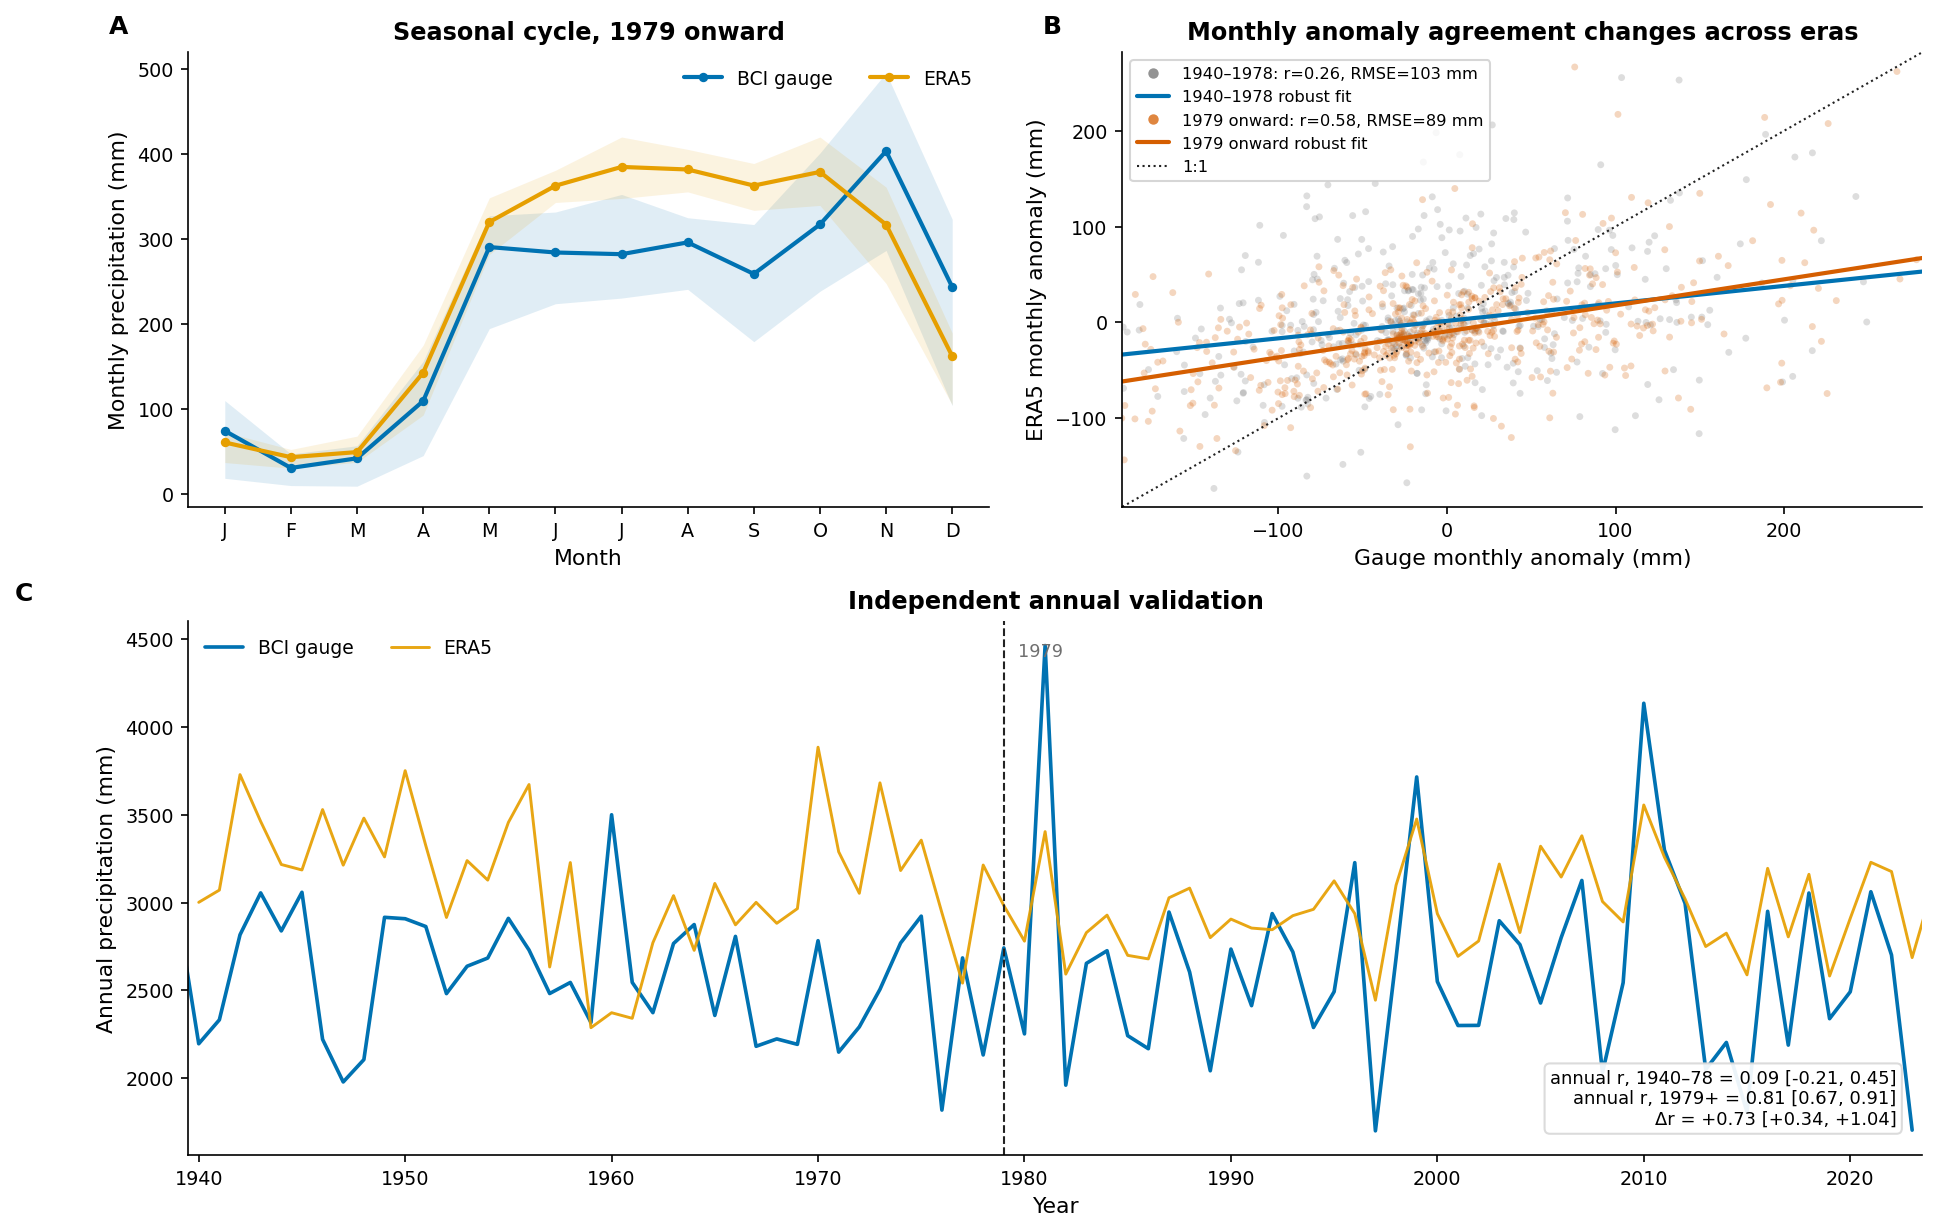

In [13]:
fig = plt.figure(figsize=(12.8, 8.1), layout="constrained")
gs = fig.add_gridspec(2, 2, height_ratios=[0.92, 1.08])

# A: modern seasonal cycle
ax = fig.add_subplot(gs[0, 0])
months = np.arange(1, 13)
for series, color, label in [
    (post_m.gauge, C["blue"], "BCI gauge"),
    (post_m.era5, C["orange"], "ERA5"),
]:
    g = series.groupby(series.index.month)
    mean = g.mean().reindex(months)
    q25 = g.quantile(0.25).reindex(months)
    q75 = g.quantile(0.75).reindex(months)
    ax.fill_between(months, q25, q75, color=color, alpha=0.12, lw=0)
    ax.plot(months, mean, color=color, lw=2.0, marker="o", ms=3.5, label=label)
ax.set_xticks(months)
ax.set_xticklabels(list("JFMAMJJASOND"))
ax.set_xlabel("Month")
ax.set_ylabel("Monthly precipitation (mm)")
ax.set_title("Seasonal cycle, 1979 onward")
ax.legend(loc="upper right", ncols=2)
panel_label(ax, "A")

# B: both anomaly eras in one axes
allx = overlap.gauge_anom.values
ally = overlap.era5_anom.values
lo = np.nanpercentile(np.r_[allx, ally], 1)
hi = np.nanpercentile(np.r_[allx, ally], 99)
ax = fig.add_subplot(gs[0, 1])
ax.scatter(
    pre_m.gauge_anom,
    pre_m.era5_anom,
    s=11,
    alpha=0.23,
    color=C["gray"],
    edgecolor="none",
    rasterized=True,
)
ax.scatter(
    post_m.gauge_anom,
    post_m.era5_anom,
    s=11,
    alpha=0.25,
    color=C["vermillion"],
    edgecolor="none",
    rasterized=True,
)
ax.plot([lo, hi], [lo, hi], color=C["black"], lw=1, ls=":")
robust_line(ax, pre_m.gauge_anom, pre_m.era5_anom, color=C["blue"], lo=lo, hi=hi)
robust_line(ax, post_m.gauge_anom, post_m.era5_anom, color=C["vermillion"], lo=lo, hi=hi)
rr_pre, ci_pre, _ = bootstrap_corr(pre_m.gauge_anom, pre_m.era5_anom, block=12, seed=101)
rr_post, ci_post, _ = bootstrap_corr(post_m.gauge_anom, post_m.era5_anom, block=12, seed=202)
rmse_pre = np.sqrt(np.mean((pre_m.era5_anom - pre_m.gauge_anom) ** 2))
rmse_post = np.sqrt(np.mean((post_m.era5_anom - post_m.gauge_anom) ** 2))
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel("Gauge monthly anomaly (mm)")
ax.set_ylabel("ERA5 monthly anomaly (mm)")
ax.set_title("Monthly anomaly agreement changes across eras")

ax.legend(
    handles=[
        Line2D(
            [0],
            [0],
            marker="o",
            lw=0,
            ms=5,
            mfc=C["gray"],
            mec="none",
            alpha=0.75,
            label=f"1940–1978: r={rr_pre:.2f}, RMSE={rmse_pre:.0f} mm",
        ),
        Line2D([0], [0], color=C["blue"], lw=2, label="1940–1978 robust fit"),
        Line2D(
            [0],
            [0],
            marker="o",
            lw=0,
            ms=5,
            mfc=C["vermillion"],
            mec="none",
            alpha=0.75,
            label=f"1979 onward: r={rr_post:.2f}, RMSE={rmse_post:.0f} mm",
        ),
        Line2D([0], [0], color=C["vermillion"], lw=2, label="1979 onward robust fit"),
        Line2D([0], [0], color=C["black"], lw=1, ls=":", label="1:1"),
    ],
    loc="upper left",
    fontsize=7.8,
    frameon=True,
)
panel_label(ax, "B")

# C: annual validation spans full width
ax = fig.add_subplot(gs[1, :])
ax.plot(ann_g.index.year, ann_g, color=C["blue"], lw=1.75, label="BCI gauge")
ax.plot(ann_e.index.year, ann_e, color=C["orange"], lw=1.40, alpha=0.92, label="ERA5")
ax.axvline(1979, color=C["black"], lw=1.0, ls="--")
ax.set_xlim(max(1939.5, ann_pair.index.year.min() - 0.5), ann_pair.index.year.max() + 0.5)
ax.set_xlabel("Year")
ax.set_ylabel("Annual precipitation (mm)")
ax.set_title("Independent annual validation")
ax.legend(loc="upper left", ncols=2)
ax.text(
    0.985,
    0.05,
    f"annual r, 1940–78 = {r_pre_a:.2f} [{ci_pre_a[0]:.2f}, {ci_pre_a[1]:.2f}]\n"
    f"annual r, 1979+ = {r_post_a:.2f} [{ci_post_a[0]:.2f}, {ci_post_a[1]:.2f}]\n"
    f"Δr = {delta_r:+.2f} [{delta_ci[0]:+.2f}, {delta_ci[1]:+.2f}]",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=8.6,
    bbox=dict(boxstyle="round,pad=.3", fc="white", ec=C["lightgray"], alpha=0.93),
)
ax.text(
    1979.7,
    0.96,
    "1979",
    transform=ax.get_xaxis_transform(),
    va="top",
    fontsize=8.5,
    color=C["gray"],
)
panel_label(ax, "C")

savefig(fig, "fig1_era5_bci_observing_system")
plt.show()

**Figure 1 | BCI as an independent check on ERA5 across an observing-system transition.** Panel A compares the modern-era seasonal cycle. Panel B removes the month-of-year climatology and overlays the two eras in a common anomaly space; the solid lines are Theil–Sen robust fits and the dotted line is 1:1. Panel C shows annual totals and reports 3-year moving-block-bootstrap intervals for annual correlations before and after 1979.

**Interpretation.** Agreement is markedly stronger after 1979 at both monthly-anomaly and annual scales. This is consistent with a richer observing system improving the atmospheric state represented by the reanalysis. ERA5 precipitation is a forecast field rather than a direct assimilation of the BCI rain gauge.


## 2. Pacific climate context: Niño 3.4 and BCI

ENSO is a coupled ocean–atmosphere mode of variability centered in the tropical Pacific. A standard measure of its oceanic state is the **Niño 3.4 SST anomaly**, averaged over 5°S–5°N and 170°W–120°W.

Here the Niño 3.4 series is derived from CMAP's NOAA OISST holdings rather than imported as a finished product. For query economy the regional mean uses a fixed 66-point subsample of the Niño 3.4 box (grid points every 2° of latitude and 5° of longitude); this thinned average tracks the canonical index closely while keeping the daily quarter-degree query small. The map below shows the December 1997 SST anomaly during the 1997–98 El Niño, the Niño 3.4 region, and the location of BCI.


In [14]:
# Fixed 66-point subsample of the Nino 3.4 box (5S-5N, 170W-120W): points every
# 2 deg of latitude and 5 deg of longitude on the OISST quarter-degree grid.
lats = [-4.875, -2.875, -0.875, 1.125, 3.125, 4.875]
lons = [round(-169.875 + 5 * k, 3) for k in range(11)]

nino = api.query("""
    SELECT YEAR([time]) AS yy, MONTH([time]) AS mm, AVG(sst) AS sst
    FROM tblSST_AVHRR_OI_NRT
    WHERE lat IN (%s) AND lon IN (%s)
      AND [time] >= '1981-09-01'
    GROUP BY YEAR([time]), MONTH([time])
    ORDER BY yy, mm
""" % (", ".join(map(str, lats)), ", ".join(map(str, lons))))

nino["time"] = pd.to_datetime(dict(year=nino.yy, month=nino.mm, day=15))
nino = nino.set_index("time").sst.sort_index()
clim = nino["1982":"2010"].groupby(nino["1982":"2010"].index.month).mean()
nino_anom = nino - nino.index.month.map(clim)
nino_3mo = nino_anom.rolling(3, center=True, min_periods=3).mean().rename("nino34")

sst_97 = api.query("""
    SELECT lat, lon, AVG(sst) AS sst
    FROM tblSST_AVHRR_OI_NRT
    WHERE [time] BETWEEN '1997-12-01' AND '1997-12-31'
      AND lat BETWEEN -16 AND 26 AND lon BETWEEN -180 AND -60
    GROUP BY lat, lon
""")
sst_dec_clim = api.query("""
    SELECT lat, lon, AVG(sst) AS sst
    FROM tblSST_AVHRR_OI_NRT
    WHERE MONTH([time]) = 12 AND [time] BETWEEN '1982-01-01' AND '2010-12-31'
      AND lat BETWEEN -16 AND 26 AND lon BETWEEN -180 AND -60
    GROUP BY lat, lon
""")
diff = sst_97.merge(sst_dec_clim, on=["lat", "lon"], suffixes=("_97", "_clim"))
diff["d_sst"] = diff.sst_97 - diff.sst_clim
grid = diff.pivot(index="lat", columns="lon", values="d_sst")

# Living trees from the most recent census, shown in Figure 2B.
# Coordinates were transformed to WGS84 during CMAP ingestion.
# Note: dbh is stored in millimeters, so dbh >= 100 selects trees >= 10 cm.
trees = api.query("""
    SELECT lat, lon, dbh
    FROM tblBCI_Census
    WHERE census = 8 AND status LIKE 'A%' AND dbh >= 100
""")

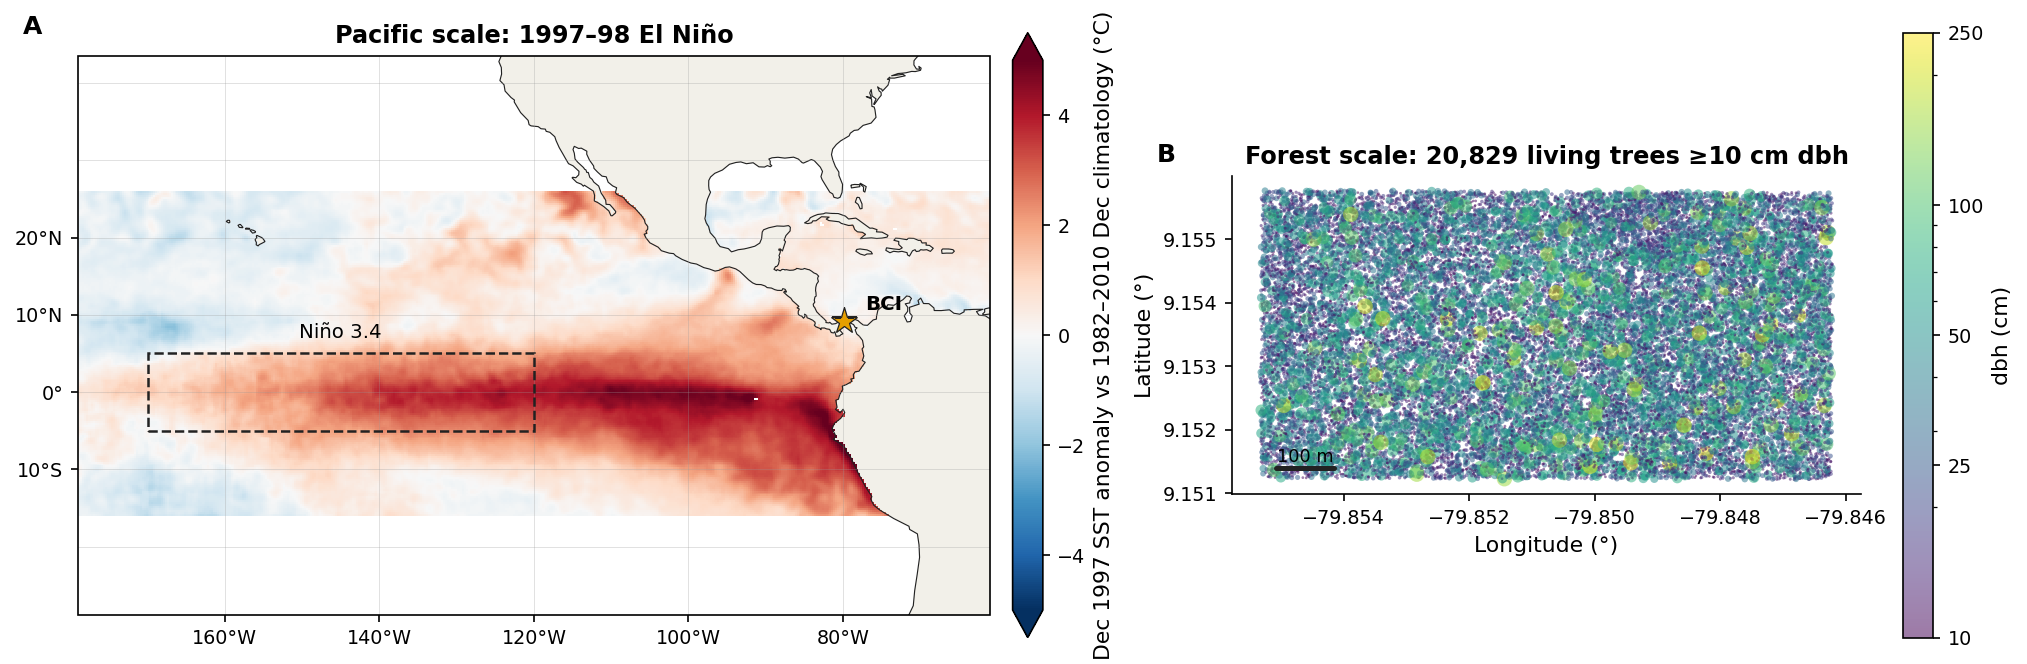

In [15]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

fig = plt.figure(figsize=(13.4, 5.0), layout="constrained")
gs = fig.add_gridspec(1, 2, width_ratios=[1.45, 1])

ax = fig.add_subplot(gs[0], projection=ccrs.PlateCarree())
ax.set_extent([-179, -61, -16, 26])
ax.add_feature(cfeature.LAND.with_scale("110m"), facecolor="#F2F0E9", edgecolor="none", zorder=0)
pc = ax.pcolormesh(
    grid.columns,
    grid.index,
    grid.values,
    cmap="RdBu_r",
    norm=mcolors.TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5),
    transform=ccrs.PlateCarree(),
    rasterized=True,
    zorder=1,
)
ax.coastlines(resolution="110m", lw=0.55, color=C["black"], zorder=2)
ax.add_patch(
    Rectangle(
        (-170, -5),
        50,
        10,
        fill=False,
        ec=C["black"],
        lw=1.2,
        ls="--",
        transform=ccrs.PlateCarree(),
        zorder=3,
    )
)
ax.text(-145, 7.0, "Niño 3.4", ha="center", fontsize=9.5, transform=ccrs.PlateCarree())
ax.plot(
    -79.8461,
    9.1543,
    marker="*",
    ms=13,
    mfc=C["orange"],
    mec=C["black"],
    mew=0.6,
    transform=ccrs.PlateCarree(),
    zorder=4,
)
ax.text(-77.2, 10.7, "BCI", fontweight="bold", fontsize=9.5, transform=ccrs.PlateCarree())


ax.gridlines(draw_labels=False, lw=0.25, color="#9A9A9A", alpha=0.55)
ax.set_xticks([-160, -140, -120, -100, -80], crs=ccrs.PlateCarree())
ax.set_yticks([-10, 0, 10, 20], crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.tick_params(labelsize=9.2)
cb = fig.colorbar(pc, ax=ax, shrink=0.82, pad=0.025, extend="both")
cb.set_label("Dec 1997 SST anomaly vs 1982–2010 Dec climatology (°C)")
ax.set_title("Pacific scale: 1997–98 El Niño")
panel_label(ax, "A", x=-0.06)

ax = fig.add_subplot(gs[1])
norm = mcolors.LogNorm(vmin=10, vmax=250)
sc = ax.scatter(
    trees.lon,
    trees.lat,
    s=np.clip((trees.dbh / 75) ** 1.45, 0.7, 55),
    c=trees.dbh / 10,
    cmap="viridis",
    norm=norm,
    alpha=0.52,
    linewidth=0,
    rasterized=True,
)
ax.set_aspect(1 / np.cos(np.deg2rad(9.1543)))
ax.ticklabel_format(useOffset=False)
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title(f"Forest scale: {len(trees):,} living trees ≥10 cm dbh")
cb = fig.colorbar(sc, ax=ax, shrink=0.82, pad=0.025)
cb.set_label("dbh (cm)")
cb.set_ticks([10, 25, 50, 100, 250])
cb.set_ticklabels(["10", "25", "50", "100", "250"])
x0 = trees.lon.min() + 0.00025
y0 = trees.lat.min() + 0.00018
dlon100 = 0.1 / (111.32 * np.cos(np.deg2rad(9.1543)))
ax.plot([x0, x0 + dlon100], [y0, y0], color=C["black"], lw=2.4)
ax.text(x0 + dlon100 / 2, y0 + 0.00010, "100 m", ha="center", fontsize=8.5)
panel_label(ax, "B", x=-0.12)

savefig(fig, "fig2_pacific_to_bci_harmonization")
plt.show()

**Figure 2 | One spatial framework from basin scale to individual organisms.** Panel A shows the December 1997 SST anomaly relative to the 1982–2010 December climatology and identifies the Niño 3.4 region used to construct the climate index. Panel B shows the georeferenced BCI tree inventory after CMAP harmonization. Tree coordinates were transformed from the original project coordinate system into WGS84 during ingestion, enabling direct spatial integration with global environmental datasets. Point size and color encode DBH to show the forest's size structure without changing the underlying locations.


## 3. ENSO and BCI hydroclimate

The **Niño 3.4 anomaly** provides a compact measure of tropical Pacific SST variability. NOAA's official Oceanic Niño Index (ONI) uses a 3-month running mean of SST anomalies in this same region, together with a prescribed SST product, climatology, and event-duration criteria. The index used here is therefore described as **ONI-like** because it is constructed directly from CMAP OISST with a fixed 1982–2010 monthly climatology.

For the statistical comparison, December Niño 3.4 is paired with the December–April BCI dry season that follows.

Two local hydroclimate dimensions are examined:

- **Water supply:** BCI gauge precipitation.
- **Atmospheric demand:** vapor pressure deficit (VPD), estimated from ERA5 2-m air temperature and dew-point temperature.

The December–April rainfall total is a seasonal rainfall metric rather than a complete drought-severity index; drought intensity also depends on timing, persistence, evaporative demand, and stored soil water.


In [16]:
dry_rain = dry_season_sum(rain.precip_total)
dry_vpd = dry_season_mean(era5.vpd_kpa).rename("dry_vpd_kpa")

dec = nino_3mo[nino_3mo.index.month == 12]
pairs = pd.DataFrame({"year": dec.index.year + 1, "nino_dec": dec.values}).set_index("year")
pairs["dry_rain_mm"] = dry_rain
pairs["dry_vpd_kpa"] = dry_vpd
pairs = pairs.dropna(subset=["nino_dec", "dry_rain_mm"])

fit_rain, bslope_rain, bint_rain, br_rain = bootstrap_regression(
    pairs.nino_dec, pairs.dry_rain_mm, block=3
)
pv0 = pairs.dropna(subset=["dry_vpd_kpa"])
fit_vpd, bslope_vpd, bint_vpd, br_vpd = bootstrap_regression(pv0.nino_dec, pv0.dry_vpd_kpa, block=3)
rho_rain = stats.spearmanr(pairs.nino_dec, pairs.dry_rain_mm)

print(
    f"Niño 3.4 → Dec-Apr rainfall: r={fit_rain.rvalue:.2f}, "
    f"Spearman ρ={rho_rain.statistic:.2f}, p={fit_rain.pvalue:.4g}; "
    f"slope={fit_rain.slope:.0f} mm/°C "
    f"[3-y block-bootstrap 95% CI {np.percentile(bslope_rain,2.5):.0f}, "
    f"{np.percentile(bslope_rain,97.5):.0f}]"
)
print(
    f"Niño 3.4 → ERA5 dry-season VPD proxy: r={fit_vpd.rvalue:.2f}, "
    f"p={fit_vpd.pvalue:.4g}; slope={fit_vpd.slope:.3f} kPa/°C"
)
pairs.to_csv(DATA_OUT / "bci_enso_hydroclimate.csv", index_label="dry_season_year")

Niño 3.4 → Dec-Apr rainfall: r=-0.43, Spearman ρ=-0.39, p=0.004319; slope=-99 mm/°C [3-y block-bootstrap 95% CI -165, -35]
Niño 3.4 → ERA5 dry-season VPD proxy: r=0.62, p=8.502e-06; slope=0.036 kPa/°C


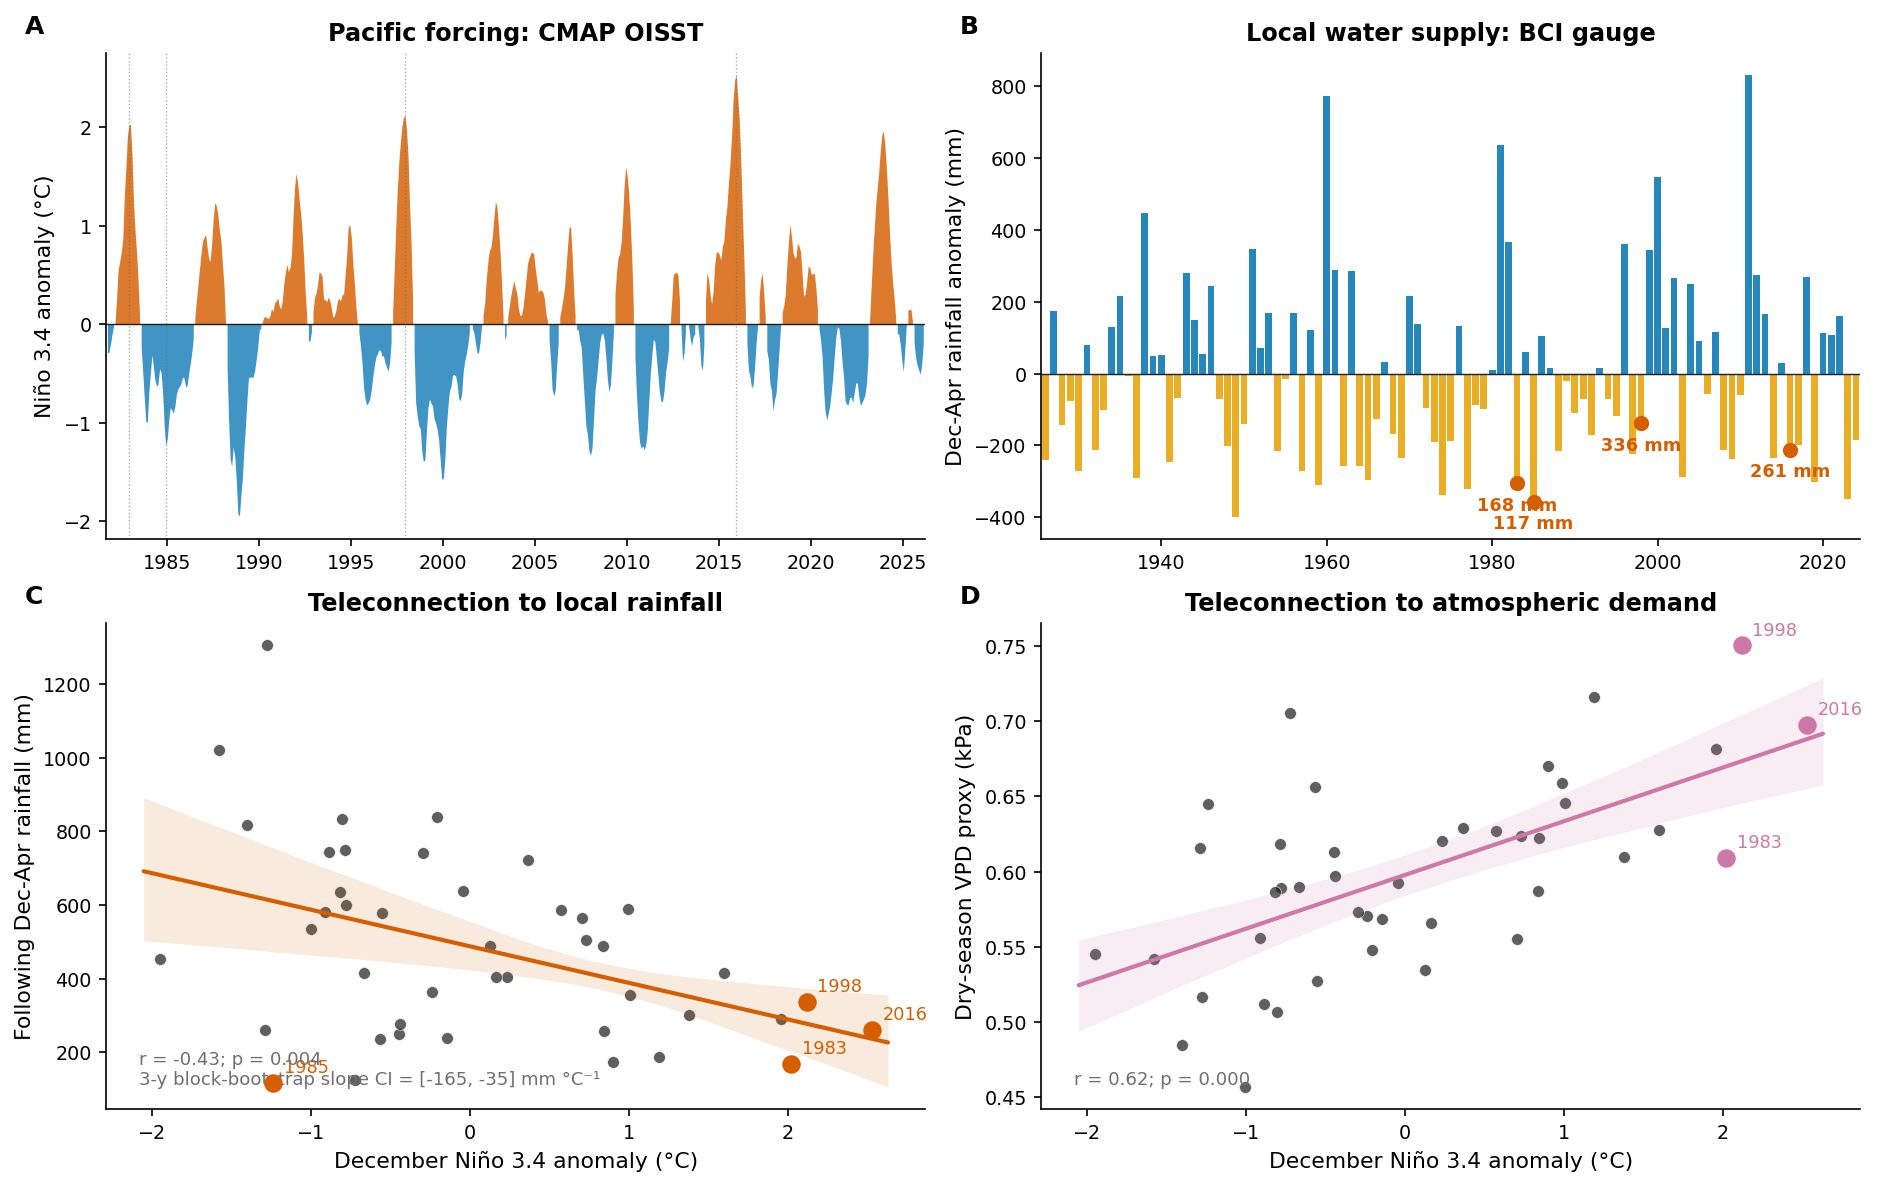

In [17]:
fig = plt.figure(figsize=(12.4, 7.8), layout="constrained")
gs = fig.add_gridspec(2, 2)

ax = fig.add_subplot(gs[0, 0])
x = decimal_year(nino_3mo.index)
y = nino_3mo.values
ax.fill_between(x, y, 0, where=y >= 0, color=C["vermillion"], alpha=0.82, lw=0)
ax.fill_between(x, y, 0, where=y < 0, color=C["blue"], alpha=0.75, lw=0)
ax.axhline(0, color=C["black"], lw=0.7)
for yr in (1983, 1985, 1998, 2016):
    ax.axvline(yr - 0.08, color=C["gray"], lw=0.65, ls=":", alpha=0.6)
ax.set_xlim(max(1981.5, x.min()), x.max())
ax.set_ylabel("Niño 3.4 anomaly (°C)")
ax.set_title("Pacific forcing: CMAP OISST")
panel_label(ax, "A")

ax = fig.add_subplot(gs[0, 1])
base = dry_rain.loc[1982:2010].mean()
vals = dry_rain - base
colors = np.where(vals < 0, C["orange"], C["blue"])
ax.bar(dry_rain.index, vals, width=0.82, color=colors, alpha=0.85, linewidth=0)
ax.axhline(0, color=C["black"], lw=0.7)
for yr in (1983, 1985, 1998, 2016):
    if yr in dry_rain.index:
        ax.scatter(yr, vals.loc[yr], s=40, color=C["vermillion"], zorder=5)
        ax.annotate(
            f"{dry_rain.loc[yr]:.0f} mm",
            (yr, vals.loc[yr]),
            xytext=(0, -13 if vals.loc[yr] < 0 else 8),
            textcoords="offset points",
            ha="center",
            fontsize=8.5,
            color=C["vermillion"],
            fontweight="semibold",
        )
ax.set_xlim(dry_rain.index.min() - 0.5, dry_rain.index.max() + 0.5)
ax.set_ylabel("Dec-Apr rainfall anomaly (mm)")
ax.set_title("Local water supply: BCI gauge")
panel_label(ax, "B")

ax = fig.add_subplot(gs[1, 0])
xv = pairs.nino_dec.values
yv = pairs.dry_rain_mm.values
ax.scatter(xv, yv, s=32, color=C["black"], alpha=0.72, edgecolor="white", linewidth=0.35)
xx = np.linspace(xv.min() - 0.1, xv.max() + 0.1, 140)
pred = bint_rain[:, None] + bslope_rain[:, None] * xx[None, :]
lo, hi = np.percentile(pred, [2.5, 97.5], axis=0)
ax.fill_between(xx, lo, hi, color=C["vermillion"], alpha=0.13, lw=0)
ax.plot(xx, fit_rain.intercept + fit_rain.slope * xx, color=C["vermillion"], lw=2)
for year in (1983, 1985, 1998, 2016):
    if year in pairs.index:
        r = pairs.loc[year]
        ax.scatter(r.nino_dec, r.dry_rain_mm, s=62, color=C["vermillion"], zorder=5)
        ax.annotate(
            str(year),
            (r.nino_dec, r.dry_rain_mm),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8.5,
            color=C["vermillion"],
        )
ax.set_xlabel("December Niño 3.4 anomaly (°C)")
ax.set_ylabel("Following Dec-Apr rainfall (mm)")
ax.set_title("Teleconnection to local rainfall")
ax.text(
    0.04,
    0.05,
    f"r = {fit_rain.rvalue:.2f}; p = {fit_rain.pvalue:.3f}\n"
    f"3-y block-bootstrap slope CI = [{np.percentile(bslope_rain,2.5):.0f}, "
    f"{np.percentile(bslope_rain,97.5):.0f}] mm °C⁻¹",
    transform=ax.transAxes,
    fontsize=8.7,
    color=C["gray"],
)
panel_label(ax, "C")

ax = fig.add_subplot(gs[1, 1])
pv = pairs.dropna(subset=["dry_vpd_kpa"])
xv = pv.nino_dec.values
yv = pv.dry_vpd_kpa.values
ax.scatter(xv, yv, s=32, color=C["black"], alpha=0.72, edgecolor="white", linewidth=0.35)
xx = np.linspace(xv.min() - 0.1, xv.max() + 0.1, 140)
pred = bint_vpd[:, None] + bslope_vpd[:, None] * xx[None, :]
lo, hi = np.percentile(pred, [2.5, 97.5], axis=0)
ax.fill_between(xx, lo, hi, color=C["purple"], alpha=0.13, lw=0)
ax.plot(xx, fit_vpd.intercept + fit_vpd.slope * xx, color=C["purple"], lw=2)
for year in (1983, 1998, 2016):
    if year in pv.index:
        r = pv.loc[year]
        ax.scatter(r.nino_dec, r.dry_vpd_kpa, s=62, color=C["purple"], zorder=5)
        ax.annotate(
            str(year),
            (r.nino_dec, r.dry_vpd_kpa),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8.5,
            color=C["purple"],
        )
ax.set_xlabel("December Niño 3.4 anomaly (°C)")
ax.set_ylabel("Dry-season VPD proxy (kPa)")
ax.set_title("Teleconnection to atmospheric demand")
ax.text(
    0.04,
    0.05,
    f"r = {fit_vpd.rvalue:.2f}; p = {fit_vpd.pvalue:.3f}",
    transform=ax.transAxes,
    fontsize=8.7,
    color=C["gray"],
)
panel_label(ax, "D")

savefig(fig, "fig3_enso_to_bci_hydroclimate")
plt.show()

**Figure 3 | Pacific SST variability is associated with two local hydroclimate dimensions.** Panel A is the ONI-like Niño 3.4 series derived from CMAP OISST. Panel B shows BCI Dec–Apr rainfall anomalies relative to 1982–2010. Panel C compares December Niño 3.4 with the following Dec–Apr rainfall using a 3-year moving-block bootstrap. Panel D compares Niño 3.4 with an ERA5 monthly-mean 2-m VPD proxy. The exceptionally dry 1985 season occurs despite a negative Niño 3.4 anomaly, illustrating that ENSO shifts the probability of dry conditions rather than determining every dry season.

Rainfall represents water supply; VPD represents atmospheric demand. Neither alone is a complete measure of plant drought stress.


## 4. Forest response: mortality depends on tree size

A census interval integrates several years of ecological history, including climate variability, competition, gap dynamics, pathogens, herbivory, and measurement timing. Mortality is therefore treated here as an interval-level demographic response rather than attributed to a single driver.

The analysis asks:

> **Does the long-term mortality trajectory differ between small stems (1–10 cm dbh) and larger trees (≥10 cm dbh)?**

The 1982–85 versus 1985–90 comparison follows the interval structure used in the classic BCI drought analysis of Condit, Hubbell & Foster (1995). Mortality is annualized from interval survival under a constant-hazard approximation.


In [18]:
mort_size = api.query("""
    SELECT a.census,
           CASE WHEN a.dbh < 100 THEN '1-10 cm' ELSE '>=10 cm' END AS size_class,
           COUNT(*) AS n_alive,
           SUM(CASE WHEN b.status LIKE 'D%' THEN 1 ELSE 0 END) AS died,
           SUM(CASE WHEN b.status LIKE 'A%' THEN 1 ELSE 0 END) AS surv,
           AVG(CAST(DATEDIFF(day, a.[time], b.[time]) AS float))/365.25 AS dt_yr,
           AVG(CAST(DATEDIFF(day, '19000101', a.[time]) AS float)) AS mean_t0_day,
           AVG(CAST(DATEDIFF(day, '19000101', b.[time]) AS float)) AS mean_t1_day
    FROM tblBCI_Census a
    JOIN tblBCI_Census b ON b.tree_id = a.tree_id AND b.census = a.census + 1
    -- dbh is stored in millimeters: 100 mm = 10 cm; the census threshold is 10 mm = 1 cm.
    WHERE a.status LIKE 'A%' AND a.dbh IS NOT NULL AND a.dbh >= 10
    GROUP BY a.census, CASE WHEN a.dbh < 100 THEN '1-10 cm' ELSE '>=10 cm' END
    ORDER BY a.census, size_class
""")

origin = pd.Timestamp("1900-01-01")
mort_size["mean_t0"] = origin + pd.to_timedelta(mort_size.mean_t0_day, unit="D")
mort_size["mean_t1"] = origin + pd.to_timedelta(mort_size.mean_t1_day, unit="D")


def annualized_mortality_ci(surv, died, dt_yr, z=1.96):
    # Wilson 95% interval for the observed survival proportion, transformed to an annualized rate.
    n = surv + died
    if n <= 0 or surv <= 0:
        return np.nan, np.nan, np.nan
    p = surv / n
    denom = 1 + z * z / n
    center = (p + z * z / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / denom
    s_lo, s_hi = max(center - half, 1e-9), min(center + half, 1 - 1e-9)
    rate = -np.log(p) / dt_yr * 100
    lo = -np.log(s_hi) / dt_yr * 100
    hi = -np.log(s_lo) / dt_yr * 100
    return rate, lo, hi


vals = mort_size.apply(lambda r: annualized_mortality_ci(r.surv, r.died, r.dt_yr), axis=1)
mort_size[["mortality", "mort_lo", "mort_hi"]] = pd.DataFrame(vals.tolist(), index=mort_size.index)
mort_size["midyear"] = decimal_year(mort_size.mean_t0 + (mort_size.mean_t1 - mort_size.mean_t0) / 2)
mort_size["startyear"] = decimal_year(mort_size.mean_t0)
mort_size["endyear"] = decimal_year(mort_size.mean_t1)
INTERVALS = {
    1: "1982-85",
    2: "1985-90",
    3: "1990-95",
    4: "1995-2000",
    5: "2000-05",
    6: "2005-10",
    7: "2010-15",
}
mort_size["interval"] = mort_size.census.map(INTERVALS)

mort_size.to_csv(DATA_OUT / "bci_mortality_by_size_interval.csv", index=False)

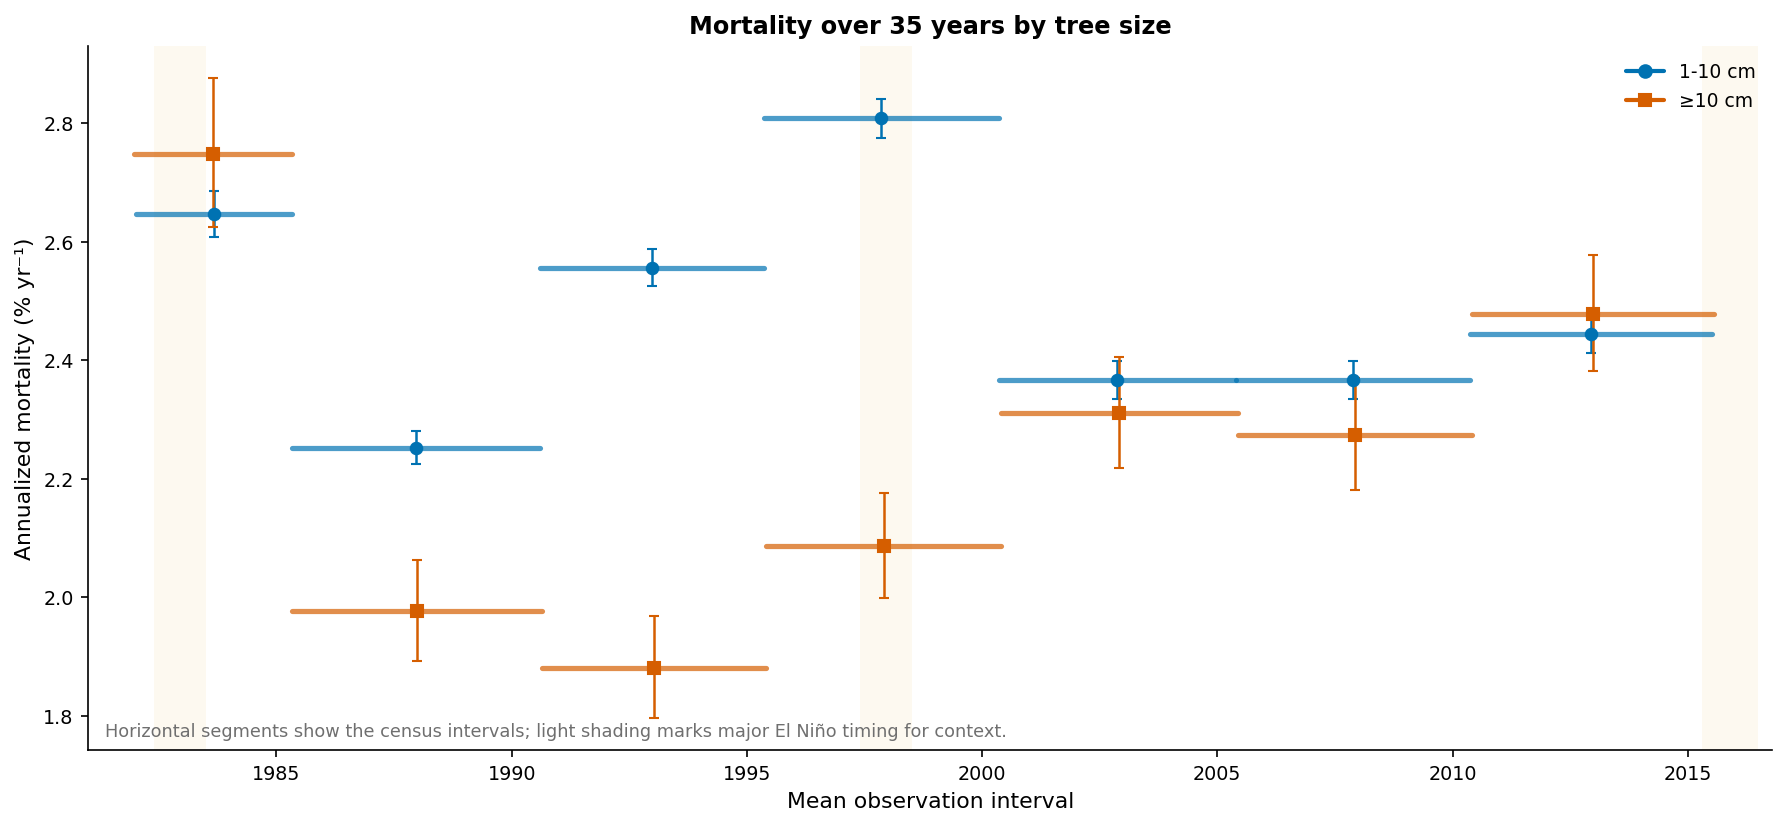

In [19]:
fig, ax = plt.subplots(figsize=(11.8, 5.4), layout="constrained")
for cls, color, marker, label in [
    ("1-10 cm", C["blue"], "o", "1-10 cm"),
    (">=10 cm", C["vermillion"], "s", "≥10 cm"),
]:
    d = mort_size[mort_size.size_class == cls].sort_values("census")
    for _, r in d.iterrows():
        ax.plot(
            [r.startyear, r.endyear], [r.mortality, r.mortality], color=color, lw=2.5, alpha=0.70
        )
        ax.errorbar(
            r.midyear,
            r.mortality,
            yerr=[[r.mortality - r.mort_lo], [r.mort_hi - r.mortality]],
            color=color,
            marker=marker,
            ms=5.5,
            lw=1.2,
            capsize=2.4,
            zorder=4,
        )
for a, b in [(1982.4, 1983.5), (1997.4, 1998.5), (2015.3, 2016.5)]:
    ax.axvspan(a, b, color=C["orange"], alpha=0.06, lw=0)
ax.set_xlim(1981, 2016.8)
ax.set_xlabel("Mean observation interval")
ax.set_ylabel("Annualized mortality (% yr⁻¹)")
ax.set_title("Mortality over 35 years by tree size")

handles = [
    Line2D([0], [0], color=C["blue"], marker="o", lw=2, label="1-10 cm"),
    Line2D([0], [0], color=C["vermillion"], marker="s", lw=2, label="≥10 cm"),
]
ax.legend(handles=handles, loc="upper right")
ax.text(
    0.01,
    0.02,
    "Horizontal segments show the census intervals; light shading marks major El Niño timing for context.",
    transform=ax.transAxes,
    fontsize=8.5,
    color=C["gray"],
)

savefig(fig, "fig4_mortality_life_stage")
plt.show()

**Figure 4 | Mortality dynamics depend on tree size and census interval.** Each estimate is shown across the mean start-to-end dates of its census interval rather than as an instantaneous observation. Vertical bars show 95% uncertainty intervals for annualized mortality. Small stems and larger trees do not follow identical mortality histories across the 35-year record.
